In [ ]:
- explain propositions -- make sure viewers understand how propositions come to be and are voted on
- load clean new data w 10 propositions -- make an outcome column per proposition so its clear if the winner was yes or no
- remove totals row from the clean csv bc serves no purpose
- at state level, what was overall outcome per proposition
- did it go yes or no --> map that w CA image map (@noahsebhat @nina @sose27 for all of you to look at I added an example notebooko on how to plot data onto a geojson CA county map, take a look at data_analysis/CA_counties_mapping.ipynb. It walks through the steps of loading a base map (that I have added to data) and mergin in a data frame (here I used the ACS05 file) and then producing a plot:) 
- overall look at political leaning per county --> look for patterns
- try to determine with our analyses what determines the county votes 

# California Proposition Voting Analysis

This notebook analyzes county-level voting patterns for 10 California propositions from the 2024 general election.

The goal is to understand whether California counties vote uniformly “blue,” or whether different policy issues reveal different county-level coalitions.

## Research Question

California has a national reputation as a deeply blue state, but that statewide identity can hide major county-level variation. This analysis asks:

**How do California counties differ in their support for statewide propositions, and what do those differences reveal about social, economic, and criminal justice politics across the state?**

This proposition dataset is especially useful because propositions show how voters respond to specific issues, not just political parties or candidates.

## What are California propositions?

California propositions are statewide ballot measures that voters decide directly. They may be placed on the ballot by the state legislature or through the citizen initiative process.

Unlike candidate elections, proposition results let us compare how counties vote on specific policy questions. For this project, that helps us see whether counties behave consistently liberal/conservative across issues, or whether different issues create different coalitions.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

The raw file contains county-level yes/no vote counts for 10 propositions. It also includes a `State Totals` row, which is useful for checking statewide results but should be removed for county-level analysis.

In [16]:
# Load clean proposition vote data
csv_path = Path('general_election_data.csv')
if not csv_path.exists():
    csv_path = Path('/mnt/data/general_election_data.csv')

df = pd.read_csv(csv_path)

# Standardize column names
cum_cols_before = df.columns.tolist()
df.columns = df.columns.str.strip().str.lower()

# Drop statewide totals row for county-level analysis
df = df[df['county'] != 'State Totals'].copy()

# Confirm there are 58 California counties
print(df.shape)
df.head()

(58, 21)


,county,prop2_yes,prop2_no,prop3_yes,prop3_no,prop4_yes,prop4_no,prop5_yes,prop5_no,prop6_yes,prop6_no,prop32_yes,prop32_no,prop33_yes,prop33_no,prop34_yes,prop34_no,prop35_yes,prop35_no,prop36_yes,prop36_no
0,Alameda,448649,196071,484349,162389,468343,177890,360323,278296,367681,259910,423122,217905,285722,345147,292675,321988,475327,158263,394629,246789
1,Alpine,445,275,521,203,478,233,362,347,366,332,383,326,292,404,230,452,500,200,392,320
2,Amador,9736,11766,9728,11687,8870,12677,5663,15732,5872,15328,6013,15567,5185,16011,10561,10316,13134,8279,16836,4686
3,Butte,49504,41057,51240,39753,49123,42212,35285,54872,34788,54114,34697,57088,32395,57717,45070,41055,62621,27105,64491,25951
4,Calaveras,10755,14732,11429,14014,10411,15164,6896,18461,7133,17873,7392,18113,5970,19143,12490,12044,15119,10037,19553,5866


## Proposition labels

These labels make the analysis easier to interpret.

In [17]:
props = [2, 3, 4, 5, 6, 32, 33, 34, 35, 36]

prop_names = {
    2: "School and community college facilities bond",
    3: "Constitutional right to marriage",
    4: "Water, wildfire, and climate bond",
    5: "Lower vote threshold for local housing/infrastructure bonds",
    6: "End involuntary servitude in prisons",
    32: "Raise state minimum wage",
    33: "Expand local rent control authority",
    34: "Restrict certain prescription drug revenues",
    35: "Permanent Medi-Cal funding",
    36: "Increase penalties for certain drug and theft crimes"
}

pd.DataFrame({
    'proposition': [f'Prop {p}' for p in props],
    'description': [prop_names[p] for p in props]
})

,proposition,description
0,Prop 2,School and community college facilities bond
1,Prop 3,Constitutional right to marriage
2,Prop 4,"Water, wildfire, and climate bond"
3,Prop 5,Lower vote threshold for local housing/infrast...
4,Prop 6,End involuntary servitude in prisons
5,Prop 32,Raise state minimum wage
6,Prop 33,Expand local rent control authority
7,Prop 34,Restrict certain prescription drug revenues
8,Prop 35,Permanent Medi-Cal funding
9,Prop 36,Increase penalties for certain drug and theft ...


## Create analysis columns

For each proposition, this creates:

- total votes
- yes vote percentage
- county-level outcome: `Yes` if yes votes beat no votes, otherwise `No`

In [18]:
for p in props:
    yes = f'prop{p}_yes'
    no = f'prop{p}_no'
    
    df[f'prop{p}_total'] = df[yes] + df[no]
    df[f'prop{p}_yes_pct'] = df[yes] / df[f'prop{p}_total']
    df[f'prop{p}_outcome'] = np.where(df[yes] > df[no], 'Yes', 'No')

# Quick check
analysis_cols = ['county', 'prop3_yes_pct', 'prop3_outcome', 'prop32_yes_pct', 'prop32_outcome', 'prop36_yes_pct', 'prop36_outcome']
df[analysis_cols].head()

,county,prop3_yes_pct,prop3_outcome,prop32_yes_pct,prop32_outcome,prop36_yes_pct,prop36_outcome
0,Alameda,0.749,Yes,0.660,Yes,0.615,Yes
1,Alpine,0.720,Yes,0.540,Yes,0.551,Yes
2,Amador,0.454,No,0.279,No,0.782,Yes
3,Butte,0.563,Yes,0.378,No,0.713,Yes
4,Calaveras,0.449,No,0.290,No,0.769,Yes


## Statewide outcomes

This table aggregates all county votes to show the statewide result for each proposition.

In [19]:
statewide_results = []

for p in props:
    yes_col = f'prop{p}_yes'
    no_col = f'prop{p}_no'
    
    total_yes = df[yes_col].sum()
    total_no = df[no_col].sum()
    total_votes = total_yes + total_no
    yes_pct = total_yes / total_votes
    outcome = 'Yes' if total_yes > total_no else 'No'
    
    statewide_results.append({
        'proposition': f'Prop {p}',
        'description': prop_names[p],
        'state_yes': total_yes,
        'state_no': total_no,
        'state_total': total_votes,
        'state_yes_pct': yes_pct,
        'state_outcome': outcome
    })

statewide_df = pd.DataFrame(statewide_results)
statewide_df[['proposition', 'description', 'state_yes_pct', 'state_outcome']].round(3)

,proposition,description,state_yes_pct,state_outcome
0,Prop 2,School and community college facilities bond,0.587,Yes
1,Prop 3,Constitutional right to marriage,0.626,Yes
2,Prop 4,"Water, wildfire, and climate bond",0.598,Yes
3,Prop 5,Lower vote threshold for local housing/infrast...,0.450,No
4,Prop 6,End involuntary servitude in prisons,0.467,No
5,Prop 32,Raise state minimum wage,0.493,No
6,Prop 33,Expand local rent control authority,0.400,No
7,Prop 34,Restrict certain prescription drug revenues,0.509,Yes
8,Prop 35,Permanent Medi-Cal funding,0.679,Yes
9,Prop 36,Increase penalties for certain drug and theft ...,0.684,Yes


### Interpretation

The statewide results show that some propositions passed clearly, while others failed statewide. But statewide results alone do not explain how counties differed internally. The rest of the notebook focuses on those county-level differences.

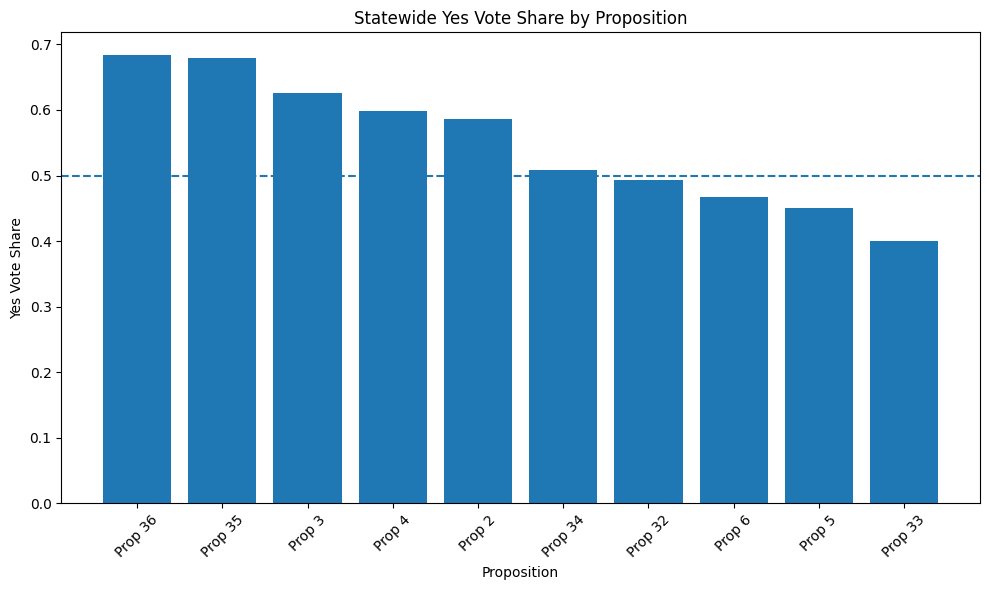

In [20]:
# Bar chart: statewide yes vote share
plot_df = statewide_df.sort_values('state_yes_pct', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_df['proposition'], plot_df['state_yes_pct'])
plt.axhline(0.5, linestyle='--')
plt.title('Statewide Yes Vote Share by Proposition')
plt.xlabel('Proposition')
plt.ylabel('Yes Vote Share')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## County-level outcomes

This table shows how many counties voted yes or no on each proposition. This is useful because a proposition can pass statewide even if county support is uneven.

In [21]:
county_outcome_summary = []

for p in props:
    yes_counties = (df[f'prop{p}_outcome'] == 'Yes').sum()
    no_counties = (df[f'prop{p}_outcome'] == 'No').sum()
    
    county_outcome_summary.append({
        'proposition': f'Prop {p}',
        'description': prop_names[p],
        'counties_yes': yes_counties,
        'counties_no': no_counties
    })

county_outcome_df = pd.DataFrame(county_outcome_summary)
county_outcome_df

,proposition,description,counties_yes,counties_no
0,Prop 2,School and community college facilities bond,39,19
1,Prop 3,Constitutional right to marriage,34,24
2,Prop 4,"Water, wildfire, and climate bond",37,21
3,Prop 5,Lower vote threshold for local housing/infrast...,7,51
4,Prop 6,End involuntary servitude in prisons,11,47
5,Prop 32,Raise state minimum wage,19,39
6,Prop 33,Expand local rent control authority,0,58
7,Prop 34,Restrict certain prescription drug revenues,31,27
8,Prop 35,Permanent Medi-Cal funding,57,1
9,Prop 36,Increase penalties for certain drug and theft ...,58,0


## Which propositions were most divisive?

To measure county-level disagreement, I calculated the standard deviation of county yes-vote percentages for each proposition. A higher standard deviation means counties were more divided; a lower standard deviation means counties voted more similarly.

In [22]:
divisive_props = []

for p in props:
    yes_pct_col = f'prop{p}_yes_pct'
    
    divisive_props.append({
        'proposition': f'Prop {p}',
        'description': prop_names[p],
        'mean_yes_pct': df[yes_pct_col].mean(),
        'std_yes_pct': df[yes_pct_col].std(),
        'min_yes_pct': df[yes_pct_col].min(),
        'max_yes_pct': df[yes_pct_col].max()
    })

divisive_df = pd.DataFrame(divisive_props).sort_values('std_yes_pct', ascending=False)
divisive_df.round(3)

,proposition,description,mean_yes_pct,std_yes_pct,min_yes_pct,max_yes_pct
1,Prop 3,Constitutional right to marriage,0.564,0.127,0.343,0.860
5,Prop 32,Raise state minimum wage,0.430,0.116,0.221,0.710
2,Prop 4,"Water, wildfire, and climate bond",0.539,0.101,0.351,0.801
4,Prop 6,End involuntary servitude in prisons,0.399,0.099,0.225,0.669
3,Prop 5,Lower vote threshold for local housing/infrast...,0.394,0.090,0.217,0.624
0,Prop 2,School and community college facilities bond,0.534,0.085,0.342,0.761
9,Prop 36,Increase penalties for certain drug and theft ...,0.705,0.071,0.534,0.826
6,Prop 33,Expand local rent control authority,0.349,0.066,0.219,0.453
8,Prop 35,Permanent Medi-Cal funding,0.656,0.065,0.478,0.782
7,Prop 34,Restrict certain prescription drug revenues,0.490,0.056,0.337,0.571


### Interpretation

The most divisive propositions were Prop 3, Prop 32, and Prop 4. These cover marriage rights, minimum wage, and climate/water bonds. This suggests that social issues, labor/economic policy, and environmental spending created some of the sharpest county-level differences.

Prop 36, which increased penalties for some drug and theft crimes, had broad support across counties, but the intensity of that support still varied meaningfully by region.

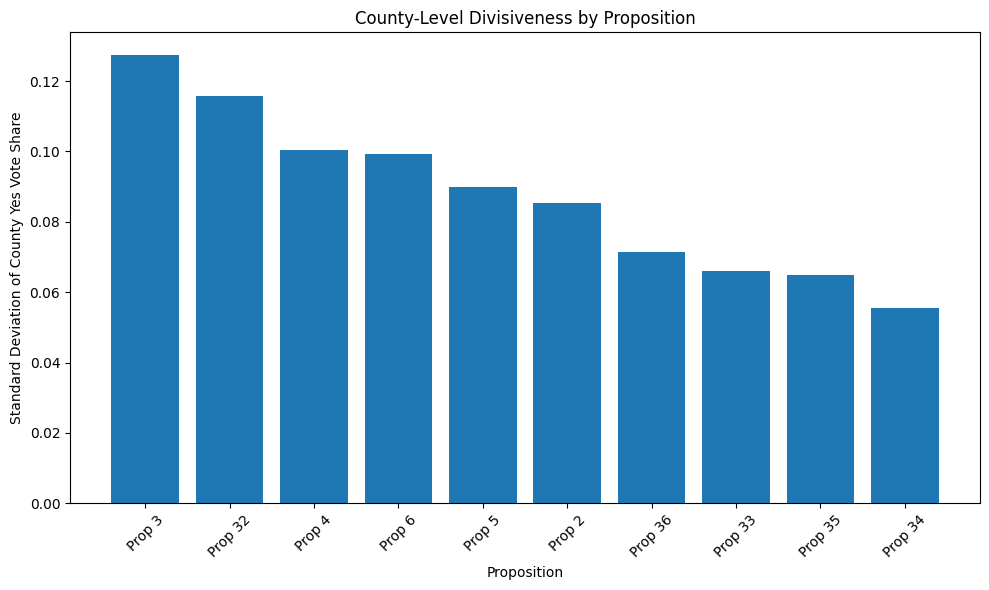

In [23]:
# Bar chart: county-level divisiveness by proposition
plot_df = divisive_df.sort_values('std_yes_pct', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_df['proposition'], plot_df['std_yes_pct'])
plt.title('County-Level Divisiveness by Proposition')
plt.xlabel('Proposition')
plt.ylabel('Standard Deviation of County Yes Vote Share')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Deep Dive 1: Prop 3 — Constitutional right to marriage

Prop 3 had the highest county-level variation. This makes it useful for examining social liberalism across California counties.

In [24]:
prop3_top = df[['county', 'prop3_yes_pct']].sort_values('prop3_yes_pct', ascending=False).head(10)
prop3_bottom = df[['county', 'prop3_yes_pct']].sort_values('prop3_yes_pct').head(10)

print('Highest support for Prop 3')
display(prop3_top.round(3))

print('Lowest support for Prop 3')
display(prop3_bottom.round(3))

Highest support for Prop 3


,county,prop3_yes_pct
20,Marin,0.860
37,San Francisco,0.847
43,Santa Cruz,0.799
48,Sonoma,0.760
40,San Mateo,0.753
0,Alameda,0.749
1,Alpine,0.720
11,Humboldt,0.713
56,Yolo,0.704
42,Santa Clara,0.698


Lowest support for Prop 3


,county,prop3_yes_pct
17,Lassen,0.343
24,Modoc,0.356
51,Tehama,0.380
44,Shasta,0.409
10,Glenn,0.416
19,Madera,0.427
50,Sutter,0.428
5,Colusa,0.429
14,Kern,0.434
53,Tulare,0.438


### Interpretation

Support for Prop 3 was strongest in Bay Area and coastal counties such as Marin, San Francisco, Santa Cruz, Sonoma, San Mateo, and Alameda. The lowest-support counties were mostly rural northern and inland counties such as Lassen, Modoc, Tehama, Shasta, Glenn, Kern, and Tulare.

This suggests that social liberalism is strongest in metropolitan coastal counties and weaker in rural/inland regions.

## Deep Dive 2: Prop 32 — Raise state minimum wage

Prop 32 is useful for comparing economic progressivism with social progressivism.

In [25]:
prop32_top = df[['county', 'prop32_yes_pct']].sort_values('prop32_yes_pct', ascending=False).head(10)
prop32_bottom = df[['county', 'prop32_yes_pct']].sort_values('prop32_yes_pct').head(10)

print('Highest support for Prop 32')
display(prop32_top.round(3))

print('Lowest support for Prop 32')
display(prop32_bottom.round(3))

Highest support for Prop 32


,county,prop32_yes_pct
37,San Francisco,0.710
0,Alameda,0.660
20,Marin,0.625
43,Santa Cruz,0.619
6,Contra Costa,0.582
48,Sonoma,0.582
42,Santa Clara,0.578
40,San Mateo,0.572
26,Monterey,0.565
12,Imperial,0.555


Lowest support for Prop 32


,county,prop32_yes_pct
17,Lassen,0.221
44,Shasta,0.249
24,Modoc,0.259
51,Tehama,0.261
2,Amador,0.279
10,Glenn,0.286
4,Calaveras,0.290
30,Placer,0.306
50,Sutter,0.313
8,El Dorado,0.313


### Interpretation

Prop 32 support was highest in many of the same progressive Bay Area counties, including San Francisco, Alameda, Marin, Santa Cruz, Contra Costa, Santa Clara, and San Mateo.

However, Monterey and Imperial also appear among the highest-support counties. This matters because these counties are not simply affluent Bay Area liberal counties. Their presence suggests that support for wage policy may also reflect working-class, service, agricultural, or Latino labor dynamics.

## Deep Dive 3: Prop 36 — Increase penalties for certain drug and theft crimes

Prop 36 passed broadly, but the county-level results show important differences in intensity of support.

In [26]:
prop36_top = df[['county', 'prop36_yes_pct']].sort_values('prop36_yes_pct', ascending=False).head(10)
prop36_bottom = df[['county', 'prop36_yes_pct']].sort_values('prop36_yes_pct').head(10)

print('Highest support for Prop 36')
display(prop36_top.round(3))

print('Lowest support for Prop 36')
display(prop36_bottom.round(3))

Highest support for Prop 36


,county,prop36_yes_pct
17,Lassen,0.826
51,Tehama,0.818
44,Shasta,0.816
10,Glenn,0.799
50,Sutter,0.797
5,Colusa,0.788
2,Amador,0.782
15,Kings,0.779
19,Madera,0.774
4,Calaveras,0.769


Lowest support for Prop 36


,county,prop36_yes_pct
43,Santa Cruz,0.534
1,Alpine,0.551
11,Humboldt,0.565
48,Sonoma,0.597
20,Marin,0.600
56,Yolo,0.601
22,Mendocino,0.603
41,Santa Barbara,0.604
25,Mono,0.613
0,Alameda,0.615


### Interpretation

The highest support for Prop 36 came from rural northern and inland counties such as Lassen, Tehama, Shasta, Glenn, Sutter, Colusa, Kings, and Madera. The lowest support came from more progressive counties such as Santa Cruz, Humboldt, Sonoma, Marin, Yolo, Mendocino, Santa Barbara, and Alameda.

This shows that even when a proposition passes statewide, counties can differ in how strongly they support it. Progressive counties were still majority-yes on Prop 36, but they were much less enthusiastic than rural and inland counties.

## County proposition profile

This section creates two simple county-level measures:

1. how many propositions each county voted yes on
2. how often each county matched the statewide outcome

These are not perfect ideology scores, but they give a quick way to compare counties across the whole proposition ballot.

In [27]:
outcome_cols = [f'prop{p}_outcome' for p in props]
df['num_yes_props'] = (df[outcome_cols] == 'Yes').sum(axis=1)

# Count how often each county matched the statewide outcome
for p in props:
    state_outcome = statewide_df.loc[statewide_df['proposition'] == f'Prop {p}', 'state_outcome'].iloc[0]
    df[f'prop{p}_matches_state'] = (df[f'prop{p}_outcome'] == state_outcome).astype(int)

match_cols = [f'prop{p}_matches_state' for p in props]
df['match_state_count'] = df[match_cols].sum(axis=1)

print('Counties voting yes on the most propositions')
display(df[['county', 'num_yes_props']].sort_values('num_yes_props', ascending=False).head(10))

print('Counties voting yes on the fewest propositions')
display(df[['county', 'num_yes_props']].sort_values('num_yes_props').head(10))

print('Counties most aligned with statewide outcomes')
display(df[['county', 'match_state_count']].sort_values('match_state_count', ascending=False).head(10))

print('Counties least aligned with statewide outcomes')
display(df[['county', 'match_state_count']].sort_values('match_state_count').head(10))

Counties voting yes on the most propositions


,county,num_yes_props
0,Alameda,8
1,Alpine,8
18,Los Angeles,8
11,Humboldt,8
37,San Francisco,8
26,Monterey,8
43,Santa Cruz,8
22,Mendocino,7
6,Contra Costa,7
20,Marin,7


Counties voting yes on the fewest propositions


,county,num_yes_props
17,Lassen,1
7,Del Norte,2
19,Madera,2
21,Mariposa,2
24,Modoc,2
31,Plumas,2
46,Siskiyou,2
45,Sierra,2
57,Yuba,2
30,Placer,3


Counties most aligned with statewide outcomes


,county,match_state_count
3,Butte,10
16,Lake,10
55,Ventura,10
36,San Diego,10
39,San Luis Obispo,10
38,San Joaquin,10
35,San Bernardino,10
32,Riverside,10
33,Sacramento,10
29,Orange,10


Counties least aligned with statewide outcomes


,county,match_state_count
17,Lassen,5
0,Alameda,6
7,Del Norte,6
1,Alpine,6
21,Mariposa,6
19,Madera,6
18,Los Angeles,6
11,Humboldt,6
24,Modoc,6
31,Plumas,6


## Main findings

1. **California is not politically uniform at the county level.** Even when statewide results look decisive, counties vary substantially in their support.

2. **Prop 3 and Prop 32 were the most useful for identifying progressive county clusters.** Bay Area and coastal counties were especially supportive of marriage rights and minimum wage increases.

3. **Prop 32 shows that economic progressivism is not only a wealthy coastal pattern.** Monterey and Imperial appearing among the highest-support counties suggests that labor and working-class dynamics may matter.

4. **Prop 36 shows broad consensus with regional differences.** It passed everywhere, but rural and inland counties supported it much more strongly than progressive coastal counties.

5. **The larger project should connect these voting patterns to demographics, education, industry, employment, and long-term partisan voting trends.**

## Final takeaway

California’s statewide blue identity hides important county-level variation. Proposition voting shows that counties do not fall along one simple red-blue spectrum. Instead, different issues create different coalitions: Bay Area counties lead on social and economic progressivism, working-class counties appear in support for wage policy, and rural/inland counties show stronger support for punitive crime measures.

In [34]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if file.endswith((".geojson", ".json", ".shp")):
            print(os.path.join(root, file))

../data/California_County_Boundaries_and_Identifiers_Blue_Version_view_5222979114348197495.geojson
../data/.ipynb_checkpoints/California_County_Boundaries_and_Identifiers_Blue_Version_view_5222979114348197495-checkpoint.geojson


In [36]:
import geopandas as gpd

counties_geo = gpd.read_file("../data/California_County_Boundaries_and_Identifiers_Blue_Version_view_5222979114348197495.geojson")

counties_geo.head()

,OBJECTID,CDTFA_COUNTY,CDTFA_COPRI,CENSUS_PLACE_NAME,CENSUS_GEOID,CENSUS_PLACE_TYPE,GNIS_PLACE_NAME,GNIS_ID,CDT_COUNTY_ABBR,PRIMARY_DOMAIN,CENSUS_POPULATION,CDT_NAME_SHORT,OFFSHORE,AREA_SQMI,GlobalID,geometry
0,82,Alameda County,01000,Alameda County,06001,County,Alameda County,1675839.000,ALA,None,None,Alameda,None,746.722,bb9da43d-5418-4c34-b53d-e4af9e649ddc,"POLYGON ((-136862.653 -21116.482, -136862.975 ..."
1,83,Alpine County,02000,Alpine County,06003,County,Alpine County,1675840.000,ALP,None,None,Alpine,None,743.407,a225a45a-a02f-4f19-a22f-d5225f0c1e3f,"POLYGON ((35904.446 77650.345, 35916.626 77625..."
2,84,Amador County,03000,Amador County,06005,County,Amador County,1675841.000,AMA,None,None,Amador,None,606.008,0f4abdae-2752-4796-96f6-ebf67b3d7301,"POLYGON ((-6292.983 76302.406, -6296.823 74295..."
3,85,Butte County,04000,Butte County,06007,County,Butte County,1675842.000,BUT,None,None,Butte,None,1677.816,88912ea1-8137-459f-bb73-bb5decc0be65,"POLYGON ((-92396.332 176240.347, -92655.136 17..."
4,86,Calaveras County,05000,Calaveras County,06009,County,Calaveras County,1675885.000,CAL,None,None,Calaveras,None,1035.547,35fb3f14-130b-40df-b575-172f53d2b67e,"POLYGON ((-1744.777 46376.992, -1748.283 46367..."


In [38]:
counties_geo.columns

Index(['OBJECTID', 'CDTFA_COUNTY', 'CDTFA_COPRI', 'CENSUS_PLACE_NAME',
       'CENSUS_GEOID', 'CENSUS_PLACE_TYPE', 'GNIS_PLACE_NAME', 'GNIS_ID',
       'CDT_COUNTY_ABBR', 'PRIMARY_DOMAIN', 'CENSUS_POPULATION',
       'CDT_NAME_SHORT', 'OFFSHORE', 'AREA_SQMI', 'GlobalID', 'geometry'],
      dtype='str')

In [40]:
counties_geo["county_clean"] = counties_geo["CENSUS_PLACE_NAME"].str.replace(" County", "", regex=False).str.strip()
df["county"] = df["county"].str.strip()

gdf = counties_geo.merge(df, left_on="county_clean", right_on="county")

gdf.shape

(58, 80)

In [41]:
import matplotlib.pyplot as plt

def make_prop_map(prop_num, title):
    col = f"prop{prop_num}_yes_pct"
    
    ax = gdf.plot(
        column=col,
        legend=True,
        figsize=(8, 10),
        edgecolor="white",
        linewidth=0.5
    )
    
    ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

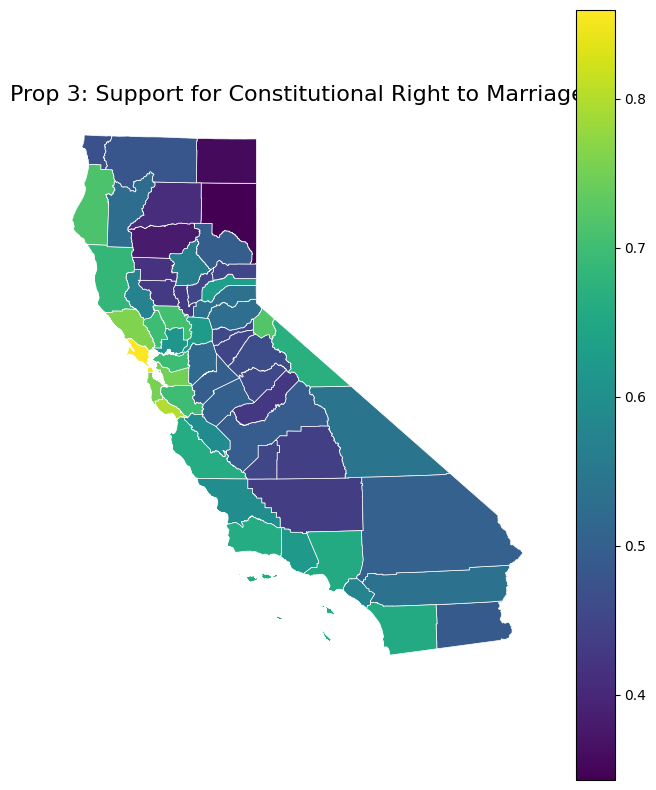

In [42]:
make_prop_map(3, "Prop 3: Support for Constitutional Right to Marriage")

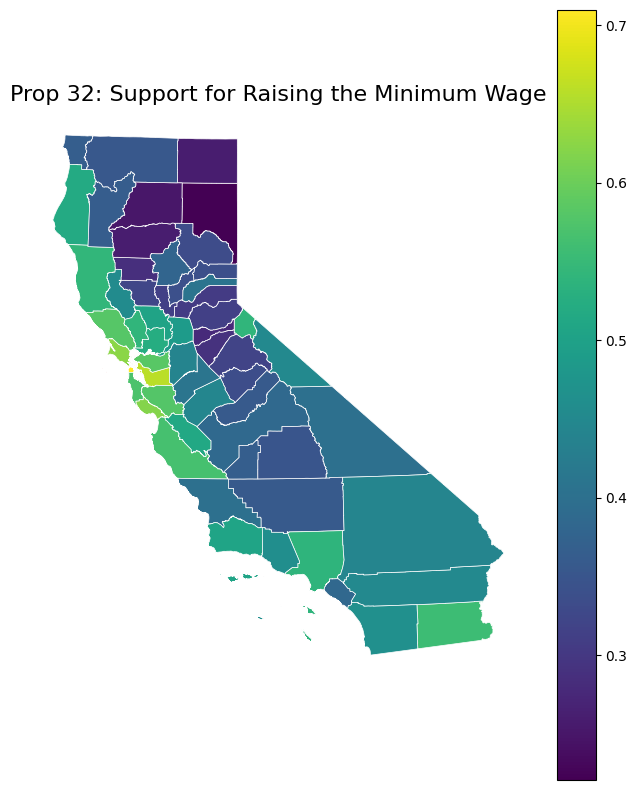

In [43]:
make_prop_map(32, "Prop 32: Support for Raising the Minimum Wage")

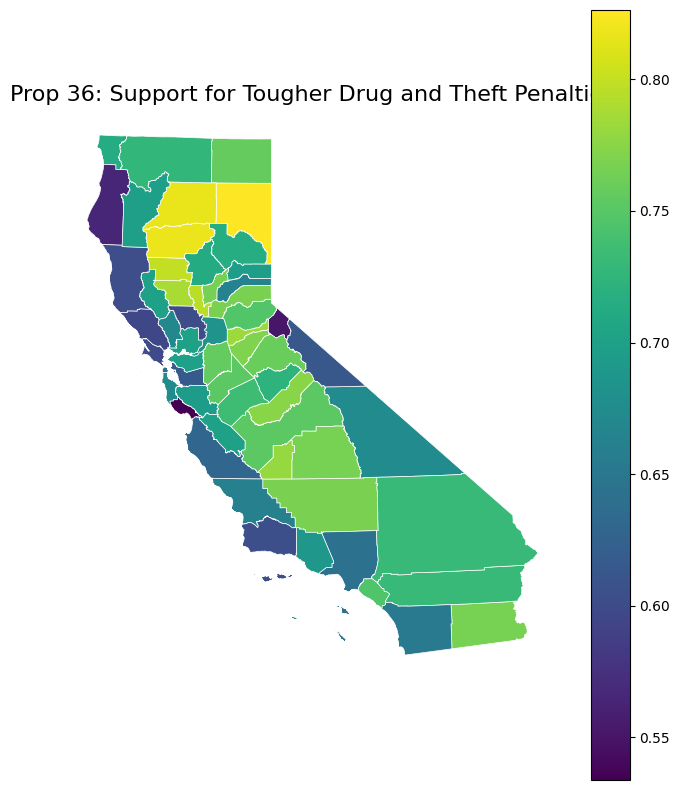

In [44]:
make_prop_map(36, "Prop 36: Support for Tougher Drug and Theft Penalties")

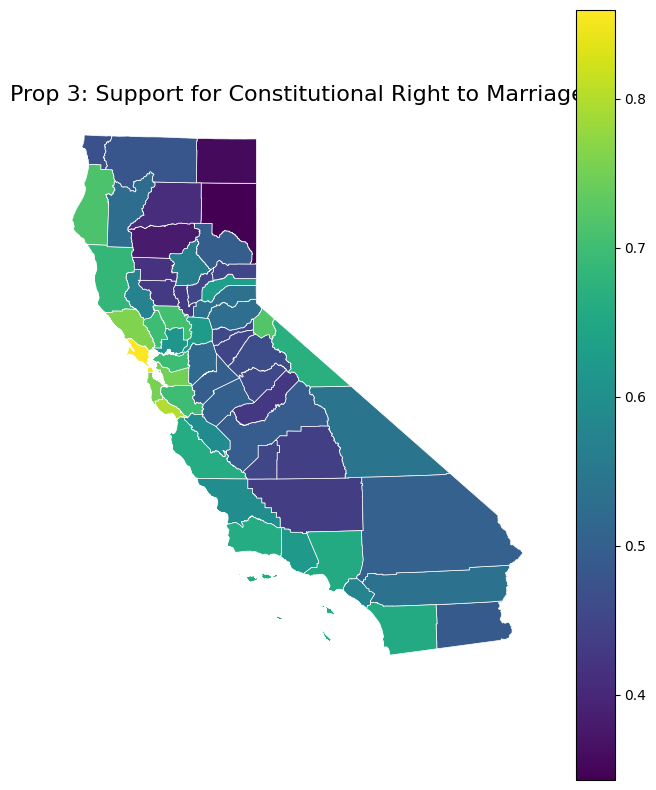

<Figure size 640x480 with 0 Axes>

In [45]:
make_prop_map(3, "Prop 3: Support for Constitutional Right to Marriage")
plt.savefig("prop3_map.png", dpi=300, bbox_inches="tight")

### California is not one political geography. Counties form different coalitions depending on whether the issue is social rights, economic policy, or criminal justice.